# TUGAS DATA MINING 04TPLP030 ARYO S.S.

**Import Library**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


**Penjelasan**

* `pandas (pd)` & `numpy (np)`: Untuk manipulasi data dan perhitungan numerik.

*  `matplotlib.pyplot` & `seaborn`: Untuk visualisasi data.

* `sklearn`: Untuk membangun model machine learning:
    * `train_test_split`: Membagi data ke dalam set pelatihan dan pengujian
    * `LabelEncoder`: Mengubah data kategorikal menjadi numerik
    * `DecisionTreeClassifier` & `RandomForestClassifier`: Algoritma klasifikasi.
    * `classification_report`, confusion_matrix: Evaluasi performa model.












**Memuat Dataset**

In [4]:
# Load dataset
df = pd.read_csv("IPM2024_with_ann_hasil.csv")
df.head()


,nama_daerah,AHHL,AHHP,HLS,IPM,PPM,Predicted_ANN
0,ACEH,68.07,71.94,14.39,74.03,14.23,Tidak Perlu Pembangunan
1,Aceh Barat,65.96,69.93,14.93,73.69,17.60,Tidak Perlu Pembangunan
2,Aceh Barat Daya,63.10,66.93,13.69,68.75,15.32,Perlu Pembangunan
3,Aceh Besar,67.80,71.69,14.77,75.13,13.21,Tidak Perlu Pembangunan
4,Aceh Jaya,65.19,69.09,14.06,71.83,12.25,Tidak Perlu Pembangunan


**Penjelasan**

* Membaca dataset `IPM2024_with_ann_hasil.csv.`

* `df.head()` digunakan untuk melihat 5 baris pertama dataset untuk pemahaman awal terhadap struktur data.

**Informasi dan Statistik Deskriptif**

In [9]:
# Informasi data
df.info()

# Statistik deskriptif
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538 entries, 0 to 537
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   nama_daerah    538 non-null    object 
 1   AHHL           538 non-null    float64
 2   AHHP           538 non-null    float64
 3   HLS            538 non-null    float64
 4   IPM            538 non-null    float64
 5   PPM            538 non-null    float64
 6   Predicted_ANN  538 non-null    object 
dtypes: float64(5), object(2)
memory usage: 29.6+ KB


,AHHL,AHHP,HLS,IPM,PPM
count,538.00000,538.000000,538.000000,538.000000,538.000000
mean,67.75132,71.579554,13.216413,72.021097,11.101041
std,3.43698,3.404325,1.276389,6.178473,6.969416
min,53.71000,57.030000,4.450000,36.300000,2.230000
25%,65.42750,69.350000,12.620000,68.970000,6.330000
50%,68.01000,71.925000,13.165000,71.835000,9.320000
75%,70.14000,73.885000,13.747500,74.937500,13.747500
max,75.99000,79.720000,17.940000,88.770000,41.420000


**Penjelasan**
* `df.info()`:
    * Menampilkan jumlah baris, kolom, nilai non-null, dan tipe data masing-masing kolom.

* `df.describe()`:
    * Statistik deskriptif (mean, min, max, std) untuk kolom numerik.

**Visualisasi Korelasi Antar Fitur**

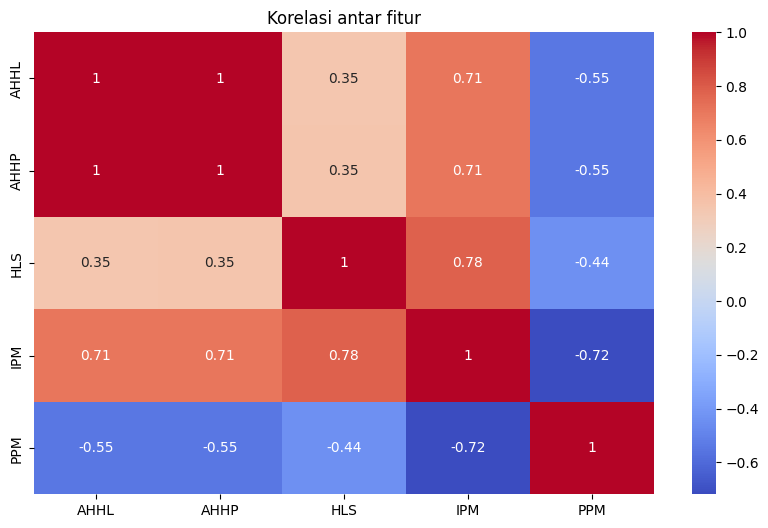

In [10]:
# Visualisasi korelasi antar fitur numerik
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Korelasi antar fitur")
plt.show()


**Penjelasan**
* `df.corr(numeric_only=True)` menghitung matriks korelasi antar fitur numerik.

* `sns.heatmap` menggambar heatmap korelasi:
    * Nilai dekat 1 atau -1 menunjukkan korelasi tinggi.
    * Berguna untuk melihat fitur mana yang saling berkaitan.



**Encoding Label dan Split Data**

In [6]:
# Encode target variabel
le = LabelEncoder()
df['target'] = le.fit_transform(df['Predicted_ANN'])

# Fitur dan target
X = df[['AHHL', 'AHHP', 'HLS', 'IPM', 'PPM']]
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Penjelasan**

* `LabelEncoder` mengubah kolom kategori `Predicted_ANN` menjadi angka (`target`) agar bisa diproses oleh algoritma machine learning.

* `X`: variabel fitur (input) — kolom-kolom terkait pembangunan manusia.

* `y`: label (target) yang ingin diprediksi.

* `train_test_split`: data dibagi menjadi 80% untuk pelatihan (`X_train, y_train`) dan 20% untuk pengujian (`X_test, y_test`).

**Training Model Decision Tree**

In [12]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        44
           1       1.00      0.98      0.99        64

    accuracy                           0.99       108
   macro avg       0.99      0.99      0.99       108
weighted avg       0.99      0.99      0.99       108



**Penjelasan**

* Membuat model `DecisionTreeClassifier` dan melatihnya pada data latih.

* Model digunakan untuk memprediksi data uji (`X_test`).

* `classification_report()` menunjukkan:
    * **Precision**: Akurasi positif yang diprediksi.

    * **Recall**: Seberapa baik model menangkap kelas positif.

    * **F1-score**: Harmoni precision dan recall.

    * **Accuracy**: Proporsi prediksi yang benar.

**Training Model Random Forest**

In [13]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        44
           1       1.00      0.97      0.98        64

    accuracy                           0.98       108
   macro avg       0.98      0.98      0.98       108
weighted avg       0.98      0.98      0.98       108



**Penjelasan**
* `RandomForestClassifier` adalah algoritma ensemble yang terdiri dari banyak pohon keputusan.

* Lebih stabil dan cenderung lebih akurat daripada decision tree tunggal.

* Evaluasi performanya juga dicetak dengan` classification_report`.

**Visualisasi Confusion Matrix**

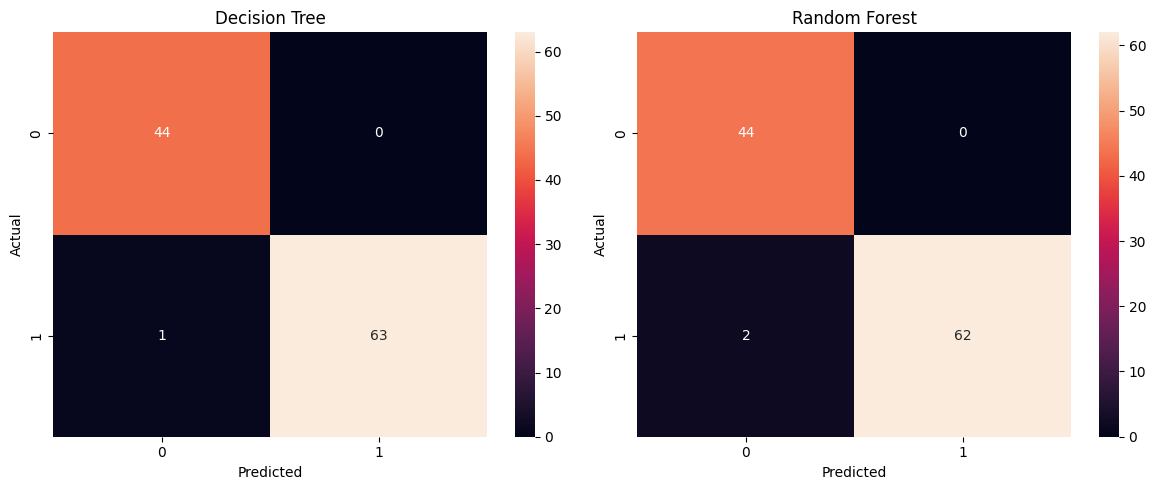

In [14]:
# Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', ax=ax[0])
ax[0].set_title("Decision Tree")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=ax[1])
ax[1].set_title("Random Forest")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()
